<a href="https://colab.research.google.com/github/Udana-Gits/My_AI_Learnings/blob/main/02_pNeumonia_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install kaggle tensorflow transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.0 MB/s eta 0:00:00


In [ ]:
import os
from google.colab import files

# 1) Upload button (will prompt you to choose kaggle.json)
uploaded = files.upload()  # select kaggle.json

# 2) Move kaggle.json into the right place for Kaggle API
os.makedirs("/root/.kaggle", exist_ok=True)

if "kaggle.json" not in uploaded:
    raise FileNotFoundError("Please upload a file named kaggle.json (Kaggle API token).")

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json
!ls -lah /root/.kaggle

Saving kaggle.json to kaggle.json
total 16K
drwxr-xr-x 2 root root 4.0K Jan 19 10:22 .
drwx------ 1 root root 4.0K Jan 19 10:21 ..
-rw------- 1 root root   63 Jan 19 10:22 kaggle.json


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content --unzip
!ls -lah /content
!find /content -maxdepth 2 -type d -name "chest_xray"

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:20<00:00, 220MB/s]
100% 2.29G/2.29G [00:20<00:00, 117MB/s]
total 24K
drwxr-xr-x 1 root root 4.0K Jan 19 10:24 .
drwxr-xr-x 1 root root 4.0K Jan 19 10:17 ..
drwxr-xr-x 7 root root 4.0K Jan 19 10:24 chest_xray
drwxr-xr-x 4 root root 4.0K Dec  9 14:41 .config
-rw-r--r-- 1 root root   63 Jan 19 10:22 kaggle.json
drwxr-xr-x 1 root root 4.0K Dec  9 14:42 sample_data
/content/chest_xray
/content/chest_xray/chest_xray


In [ ]:
import tensorflow as tf

DATA_DIR = "/content/chest_xray"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 1337

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/val",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/test",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
class_names

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


['NORMAL', 'PNEUMONIA']

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.05),
], name="aug")

base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
)

base.trainable = False  # warm-up first

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug (Sequential)                │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,133 (15.46 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("/content/pneumonia_tf_best.keras", save_best_only=True, monitor="val_accuracy"),
    tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True, monitor="val_accuracy")
]

history = model.fit(train_ds, validation_data=val_ds, epochs=3, callbacks=callbacks)

Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 230ms/step - accuracy: 0.8459 - loss: 0.3541 - val_accuracy: 0.8750 - val_loss: 0.3031
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9299 - loss: 0.1666 - val_accuracy: 0.8750 - val_loss: 0.2152
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9440 - loss: 0.1502 - val_accuracy: 0.8750 - val_loss: 0.2386


In [ ]:
base.trainable = True
# keep training stable by using low LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(train_ds, validation_data=val_ds, epochs=2, callbacks=callbacks)

Epoch 1/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 346ms/step - accuracy: 0.7923 - loss: 0.4678 - val_accuracy: 0.9375 - val_loss: 0.2668
Epoch 2/2
163/163 ━━━━━━━━━━━━━━━━━━━━ 55s 334ms/step - accuracy: 0.9303 - loss: 0.2279 - val_accuracy: 1.0000 - val_loss: 0.2029


In [ ]:
model = tf.keras.models.load_model("/content/pneumonia_tf_best.keras")

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.8491 - loss: 0.3888
Test accuracy: 0.8878205418586731


In [ ]:
import numpy as np
from PIL import Image
import glob, random, os

def predict_one(image_path):
    img = Image.open(image_path).convert("RGB").resize(IMG_SIZE)
    x = np.array(img, dtype=np.float32)
    x = np.expand_dims(x, axis=0)  # (1,224,224,3)
    probs = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    return class_names[pred_idx], float(probs[pred_idx]), probs

# sample an image
sample_path = random.choice(glob.glob(f"{DATA_DIR}/test/*/*.jpeg"))
sample_path

'/content/chest_xray/test/NORMAL/NORMAL2-IM-0241-0001.jpeg'

In [ ]:
pred_label, confidence, probs = predict_one(sample_path)
pred_label, confidence, dict(zip(class_names, probs.tolist()))

('NORMAL',
 0.7541666030883789,
 {'NORMAL': 0.7541666030883789, 'PNEUMONIA': 0.2458333969116211})

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

LLM_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
llm = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL,
    device_map="auto",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
)

gen = pipeline("text-generation", model=llm, tokenizer=tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
def triage_level(pred, conf):
    if pred == "PNEUMONIA" and conf >= 0.90:
        return "High"
    if pred == "PNEUMONIA" and conf >= 0.75:
        return "Medium"
    return "Low"

def make_incident_report(patient_id, pred, conf):
    triage = triage_level(pred, conf)

    prompt = f"""
You are generating an EDUCATIONAL radiology triage incident report from an AI screening model.
Hard rules:
- Do NOT claim a confirmed diagnosis.
- Do NOT invent imaging findings (no locations, no consolidation/effusion statements).
- Only restate the model prediction and provide cautious next steps.

Return exactly these sections:
Summary:
Model Output:
Triage Level:
Recommended Next Steps:
Disclaimer:

Input:
Patient ID: {patient_id}
Prediction: {pred}
Confidence: {conf:.2f}
""".strip()

    text = gen(
        prompt,
        max_new_tokens=180,
        temperature=0.3,
        top_p=0.9,
        do_sample=True,
        repetition_penalty=1.1
    )[0]["generated_text"]

    return text

In [ ]:
patient_id = os.path.basename(sample_path).split(".")[0]
report_text = make_incident_report(patient_id, pred_label, confidence)

print("Image:", sample_path)
print("Prediction:", pred_label, "Confidence:", confidence)
print("\n--- REPORT ---\n")
print(report_text)

Image: /content/chest_xray/test/NORMAL/NORMAL2-IM-0241-0001.jpeg
Prediction: NORMAL Confidence: 0.7541666030883789

--- REPORT ---

You are generating an EDUCATIONAL radiology triage incident report from an AI screening model.
Hard rules:
- Do NOT claim a confirmed diagnosis.
- Do NOT invent imaging findings (no locations, no consolidation/effusion statements).
- Only restate the model prediction and provide cautious next steps.

Return exactly these sections:
Summary:
Model Output:
Triage Level:
Recommended Next Steps:
Disclaimer:

Input:
Patient ID: NORMAL2-IM-0241-0001
Prediction: NORMAL
Confidence: 0.75
Next Steps:
- Review for signs of infection or other abnormalities
- Refer for further evaluation if necessary

Patient Information:
Name: NORMAL2-IM-0241-0001
Gender: Male
Age: 35
Height: 6'0"
Weight: 200 lbs
Ethnicity: White

Physical Examination:
- No abnormal findings on physical exam

Imaging Studies:
- Computed Tomography (CT) scan: Normal
- Magnetic Resonance Imaging (MRI): N

In [ ]:
def predict_and_report(image_path):
    pred, conf, probs = predict_one(image_path)
    pid = os.path.basename(image_path).split(".")[0]
    report = make_incident_report(pid, pred, conf)
    return {
        "patient_id": pid,
        "image_path": image_path,
        "prediction": pred,
        "confidence": conf,
        "probabilities": dict(zip(class_names, probs.tolist())),
        "report": report
    }

result = predict_and_report(sample_path)
result["prediction"], result["confidence"]

('NORMAL', 0.7541666030883789)

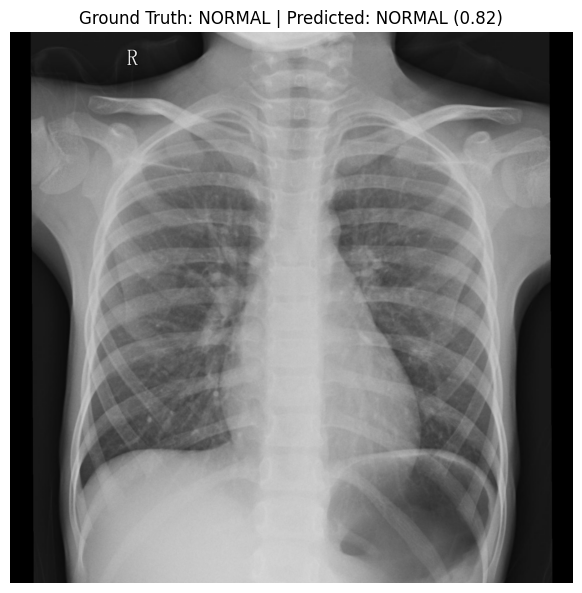

Saved: /content/pred_vs_gt.png
Image used: /content/chest_xray/test/NORMAL/NORMAL2-IM-0107-0001.jpeg


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os, glob, random
from PIL import Image

# Assumes you already have:
# - DATA_DIR = "/content/chest_xray"
# - class_names (e.g., ["NORMAL","PNEUMONIA"])
# - IMG_SIZE = (224,224)
# - predict_one(image_path) defined and working

def ground_truth_from_path(image_path):
    # .../test/NORMAL/xxx.jpeg -> "NORMAL"
    return os.path.basename(os.path.dirname(image_path))

# pick a random test image
image_path = random.choice(glob.glob(f"{DATA_DIR}/test/*/*.jpeg"))

gt = ground_truth_from_path(image_path)
pred, conf, probs = predict_one(image_path)

img = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Ground Truth: {gt} | Predicted: {pred} ({conf:.2f})")
plt.tight_layout()
plt.savefig("/content/pred_vs_gt.png", dpi=160)
plt.show()

print("Saved:", "/content/pred_vs_gt.png")
print("Image used:", image_path)